In [1]:
!pip install pandas numpy matplotlib python-dotenv tabulate


In [1]:
"""
    CASE 1
"""

'\n    CASE 1\n'

In [2]:
#Imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from Bot import TradingBot
from Patterns.Template.strategy_template import TradingStrategyTemplate
from Patterns.Strategies.GridSearchStrategy import GridSearchStrategy
from Data_Initializer.initializer import DataLoader
from Indicator.calculator import IndicatorCalculator
from Patterns.Observer import LoggingObserver

sys.path.append(os.getcwd())

In [3]:
# Rules
# Entry Rule
ENTRY_RULES = [
    "RSI_20", "RSI_25", "RSI_30", "RSI_40", 
    "BB_Reversal", "KAMA_ST"
]

# Exit Rule 
# RSI (4) + ST (1) + BB_A (1) + BB_B (7)
BB_B_RATIOS = ["0.10", "0.15", "0.20", "0.25", "0.30", "0.35", "0.40"]
BB_B_EXITS = [f"BB_B_{r}" for r in BB_B_RATIOS]

EXIT_RULES = [
    "RSI_60", "RSI_50", "RSI_45", "RSI_40", 
    "ST_BUY", 
    "BB_A"
] + BB_B_EXITS

ASSETS = ["BTCUSDT", "ETHUSDT"]
TIMEFRAMES = ["1h", "4h", "1d"]
BACKTEST_START_DATE = "1 Jan, 2022"
RESULTS_DF = pd.DataFrame(columns=[
    'Asset', 'Timeframe', 'Entry_Rule', 'Exit_Rule', 
    'Total_PnL_USD', 'Win_Rate', 'Completed_Trades'
])

CASE1_LOG_FILE = "case1_grid_trade_log.txt"

In [4]:
# Grid-Search Loop & GRID SUMMARY TABLE

grid_logger = LoggingObserver(log_file=CASE1_LOG_FILE)
data_loader = DataLoader()
indicator_calculator = IndicatorCalculator()

for asset in ASSETS:
    for tf in TIMEFRAMES:
        print(f"\n--- Loading Data for {asset} on {tf} ---")

        # Load Data (API)
        historical_data = data_loader.download_crypto_data_interval_backtest(
            api_key=os.getenv("BINANCE_API_KEY"),
            api_secret=os.getenv("BINANCE_API_SECRET"),
            symbol=asset,
            interval=tf,
            check_date=BACKTEST_START_DATE 
        )
        
        # Calculate Indicators (If there is a data extraction error, this will throw an error)
        df_processed = indicator_calculator.calculate_indicators(historical_data)
        
        if len(df_processed) == 0:
            print(f"⚠️ {asset}/{tf} no Valid data, Skipping")
            continue

        # --- Grid Loop ---
        for entry_id in ENTRY_RULES:
            for exit_id in EXIT_RULES:
                
                print(f"Testing: Entry={entry_id}, Exit={exit_id}...")
                
                # Initialize the bot and strategy
                bot = TradingBot(coin_symbol=asset)
                # Stop loss is not needed for Case 1
                grid_strategy = GridSearchStrategy(entry_id, exit_id, stop_loss=0.02)
                bot.set_strategy(grid_strategy)

                bot.register_observer(grid_logger) # register the logger to the bot
                
                # Start Backtest
                final_balance = bot.backtest_trading(
                    initial_balance=10000, 
                    stop_loss=0.02, 
                    df_with_indicators=df_processed,
                    position_size_pct=1.0 # For full balance usage
                )
                
                # Save Results
                pnl = final_balance - 10000 
                trade_stats = bot.get_trade_statistics()

                new_row = {
                    'Asset': asset,
                    'Timeframe': tf,
                    'Entry_Rule': entry_id,
                    'Exit_Rule': exit_id,
                    'Total_PnL_USD': round(pnl, 5),
                    'Final_Balance': round(final_balance, 5),
                    'Win_Rate': trade_stats['win_rate'],
                    'Completed_Trades': trade_stats['completed_trades']
                }
                
                global RESULTS_DF
                RESULTS_DF.loc[len(RESULTS_DF)] = new_row

print("\n--- ✅ Grid-Search Completed ---")
print(RESULTS_DF.sort_values(by='Total_PnL_USD', ascending=False).head())

RESULTS_FILE = "case1_grid_search_results.csv"
RESULTS_DF.to_csv(RESULTS_FILE, index=False)

print(f"\n📊 All Grid Results Saved: {RESULTS_FILE}")
print(f"📝 Detailed Logs Recorded: {CASE1_LOG_FILE}")

[LOG] LoggingObserver initialized - Log target: case1_grid_trade_log.txt

--- Loading Data for BTCUSDT on 1h ---
✅ Backtest data loaded: 34342 rows from 1 Jan, 2022
✅ Indicators calculated successfully. 34240 rows available.
Testing: Entry=RSI_20, Exit=RSI_60...
🤖 TradingBot initialized for BTCUSDT
✅ Observer registered: LoggingObserver

🔙 Starting BACKTEST for BTCUSDT
   Initial Balance: $10000.00
   Position Size: 100.0%
📊 Processing 34240 candles...
ℹ️ Backtest sonu: Kalan pozisyon 0.18310963540038686 adet BTCUSDT $86510.77 fiyattan satıldı.

📊 Backtest Complete!
   Final Balance: $15840.96
   Profit/Loss: $5840.96 (58.41%)


Testing: Entry=RSI_20, Exit=RSI_50...
🤖 TradingBot initialized for BTCUSDT
✅ Observer registered: LoggingObserver

🔙 Starting BACKTEST for BTCUSDT
   Initial Balance: $10000.00
   Position Size: 100.0%
📊 Processing 34240 candles...
ℹ️ Backtest sonu: Kalan pozisyon 0.15874081100587664 adet BTCUSDT $86510.77 fiyattan satıldı.

📊 Backtest Complete!
   Final Balanc

In [5]:
try:
    df = pd.read_csv("case1_grid_search_results.csv")

    df_sorted = df.sort_values(
        by=['Total_PnL_USD', 'Timeframe'],
        ascending=[False, True]
    )
    df_btc = df_sorted[df_sorted['Asset'] == 'BTCUSDT']
    df_eth = df_sorted[df_sorted['Asset'] == 'ETHUSDT']
    print("--- BTCUSDT Grid Search Results (Sorted by PnL) ---")
    print(df_btc.head(20).to_markdown(index=False))
    print("\n--- ETHUSDT Grid Search Results (Sorted by PnL) ---")
    print(df_eth.head(20).to_markdown(index=False))

except FileNotFoundError:
    print("HATA: 'case1_grid_search_results.csv' file was not found. Please check the name and path of the file.")

--- BTCUSDT Grid Search Results (Sorted by PnL) ---
| Asset   | Timeframe   | Entry_Rule   | Exit_Rule   |   Total_PnL_USD |   Win_Rate |   Completed_Trades |
|:--------|:------------|:-------------|:------------|----------------:|-----------:|-------------------:|
| BTCUSDT | 4h          | RSI_25       | ST_BUY      |        16671.8  |        100 |                 22 |
| BTCUSDT | 4h          | RSI_25       | RSI_60      |        15675.6  |        100 |                 20 |
| BTCUSDT | 4h          | KAMA_ST      | BB_B_0.15   |        13861.8  |        100 |                 69 |
| BTCUSDT | 4h          | KAMA_ST      | BB_B_0.20   |        13861.8  |        100 |                 69 |
| BTCUSDT | 4h          | KAMA_ST      | BB_B_0.10   |        13800.5  |        100 |                 69 |
| BTCUSDT | 4h          | KAMA_ST      | BB_B_0.25   |        13564.1  |        100 |                 67 |
| BTCUSDT | 4h          | KAMA_ST      | BB_B_0.35   |        13233    |        100 |       

In [6]:
# BEST COMBINATION TRADE LIST

#Uploading the Detailed Log File
LOG_FILE = "case1_grid_trade_log.txt"
try:
    with open(LOG_FILE, 'r', encoding='utf-8', errors='ignore') as f:
        log_lines = f.readlines()
except FileNotFoundError:
    print(f"❌ ERROR: {LOG_FILE} not found. Transaction details cannot be displayed..")
    log_lines = []

# Chooses the best combo based on the asset
def get_best_combo_trades(asset_symbol: str, results_df: pd.DataFrame, log_lines: list) -> tuple:
    # Filter asset and sort by PnL
    asset_results = results_df[results_df['Asset'] == asset_symbol]
    if asset_results.empty:
        return None, pd.DataFrame()
        
    best_combo = asset_results.sort_values(by='Total_PnL_USD', ascending=False).iloc[0]
    best_entry = best_combo['Entry_Rule']
    best_exit = best_combo['Exit_Rule']
    
   # Filter the logs and convert them into tables
    trade_list = []
    entry_info = {} # Keeps open position information

    for line in log_lines:
        if f"Strategy: GridSearchStrategy" in line and f"Bought {asset_symbol}" in line or f"Sold {asset_symbol}" in line:
            parts = line.split(',')
            timestamp_str = str(parts[1].split(': ')[1])
            if "Sold" in line and f"Trigger: {best_exit}" in line:
                try:
                    sell_price = float(parts[2].split(': ')[1])
                    pnl_str = [p for p in parts if 'PnL:' in p][0]
                    pnl_usd = float(pnl_str.split(': $')[1].split(' (')[0])
                except (IndexError, ValueError):
                    continue
                if entry_info.get('strategy') == f"GridSearchStrategy (Entry: {best_entry})":
                    duration = pd.to_datetime(timestamp_str) - entry_info['date']
                    trade_list.append({
                        'Action': 'SELL',
                        'Date': timestamp_str,
                        'Price': round(sell_price, 2),
                        'PnL_USD': round(pnl_usd, 2),
                        'PnL_%': round((sell_price / entry_info['price'] - 1) * 100, 2),
                        'Duration': str(duration),
                        'Entry_Rule': best_entry,
                        'Exit_Rule': best_exit
                    })
                    entry_info = {} # Close the position

            elif "Bought" in line and f"Trigger: {best_entry}" in line and entry_info == {}:
                try:
                    entry_price = float(parts[2].split(': ')[1])
                    position_size = float(parts[4].split(': ')[1])
                except (IndexError, ValueError):
                    continue
                entry_info = {
                    'date': pd.to_datetime(timestamp_str),
                    'price': entry_price,
                    'position': position_size,
                    'strategy': f"GridSearchStrategy (Entry: {best_entry})"
                }
                
    return best_combo, pd.DataFrame(trade_list)

#Calculate Results for BTCUSDT (Bitcoin)
btc_combo, btc_trade_list = get_best_combo_trades('BTCUSDT', RESULTS_DF, log_lines)

if btc_combo is not None:
    print("\n" + "="*80)
    print("🏆 BTCUSDT BEST COMBINATION CHOSEN:")
    print(f"   Time Frame: {btc_combo['Timeframe']}, Entry Rule: {btc_combo['Entry_Rule']}, Exit Rule: {btc_combo['Exit_Rule']}")
    print(f"   Total Profit/Loss: ${btc_combo['Total_PnL_USD']:.2f}")
    
    print("\n--- BTCUSDT BEST COMBINATION TRADE DETAILS (First 10 Transactions) ---")
    if not btc_trade_list.empty:
        print(btc_trade_list.head(10).to_markdown(index=False))
    else:
        print("No completed transactions were found for BTCUSDT in the log file.")
else:
    print("\nBTCUSDT data not found in Grid Results table.")


# Calculate Results for ETHUSDT (Ethereum)
eth_combo, eth_trade_list = get_best_combo_trades('ETHUSDT', RESULTS_DF, log_lines)

if eth_combo is not None:
    print("\n" + "="*80)
    print("🏆 ETHUSDT BEST COMBINATION CHOSEN:")
    print(f"   Time Frame: {eth_combo['Timeframe']}, Entry Rule: {eth_combo['Entry_Rule']}, Exit Rule: {eth_combo['Exit_Rule']}")
    print(f"   Total Profit/Loss: ${eth_combo['Total_PnL_USD']:.2f}")

    print("\n--- ETHUSDT BEST COMBINATION TRADE DETAILS (First 10 Transactions) ---")
    if not eth_trade_list.empty:
        print(eth_trade_list.head(10).to_markdown(index=False))
    else:
        print("No completed transactions for ETHUSDT were found in the log file.")
else:
    print("\nETHUSDT data was not found in the Grid Results table.")


🏆 BTCUSDT BEST COMBINATION CHOSEN:
   Time Frame: 4h, Entry Rule: RSI_25, Exit Rule: ST_BUY
   Total Profit/Loss: $16671.85

--- BTCUSDT BEST COMBINATION TRADE DETAILS (First 10 Transactions) ---
| Action   | Date                |   Price |   PnL_USD |   PnL_% | Duration          | Entry_Rule   | Exit_Rule   |
|:---------|:--------------------|--------:|----------:|--------:|:------------------|:-------------|:------------|
| SELL     | 2022-01-13 17:00:00 | 44154.5 |     42.65 |    0.43 | 7 days 18:00:00   | RSI_25       | ST_BUY      |
| SELL     | 2022-01-31 20:00:00 | 38473   |      1.93 |    0.02 | 10 days 14:00:00  | RSI_25       | ST_BUY      |
| SELL     | 2022-03-01 01:00:00 | 43026.4 |    263.57 |    2.62 | 11 days 08:00:00  | RSI_25       | ST_BUY      |
| SELL     | 2022-03-09 06:00:00 | 41217.7 |    132.58 |    1.29 | 4 days 12:00:00   | RSI_25       | ST_BUY      |
| SELL     | 2022-03-14 10:00:00 | 39078.9 |    375.88 |    3.6  | 0 days 09:00:00   | RSI_25       | ST_BU


--- Chart data loading: BTCUSDT (4h) ---
✅ Backtest data loaded: 600 rows from 100 days ago UTC
✅ Indicators calculated successfully. 498 rows available.


C:\Users\mst29\AppData\Local\Temp\ipykernel_4844\1811317306.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  buy_dates_raw = pd.Index(pd.to_datetime(buy_signals['Date']).dt.floor('S'))
C:\Users\mst29\AppData\Local\Temp\ipykernel_4844\1811317306.py:36: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  sell_dates_raw = pd.Index(pd.to_datetime(sell_signals['Date']).dt.floor('S'))


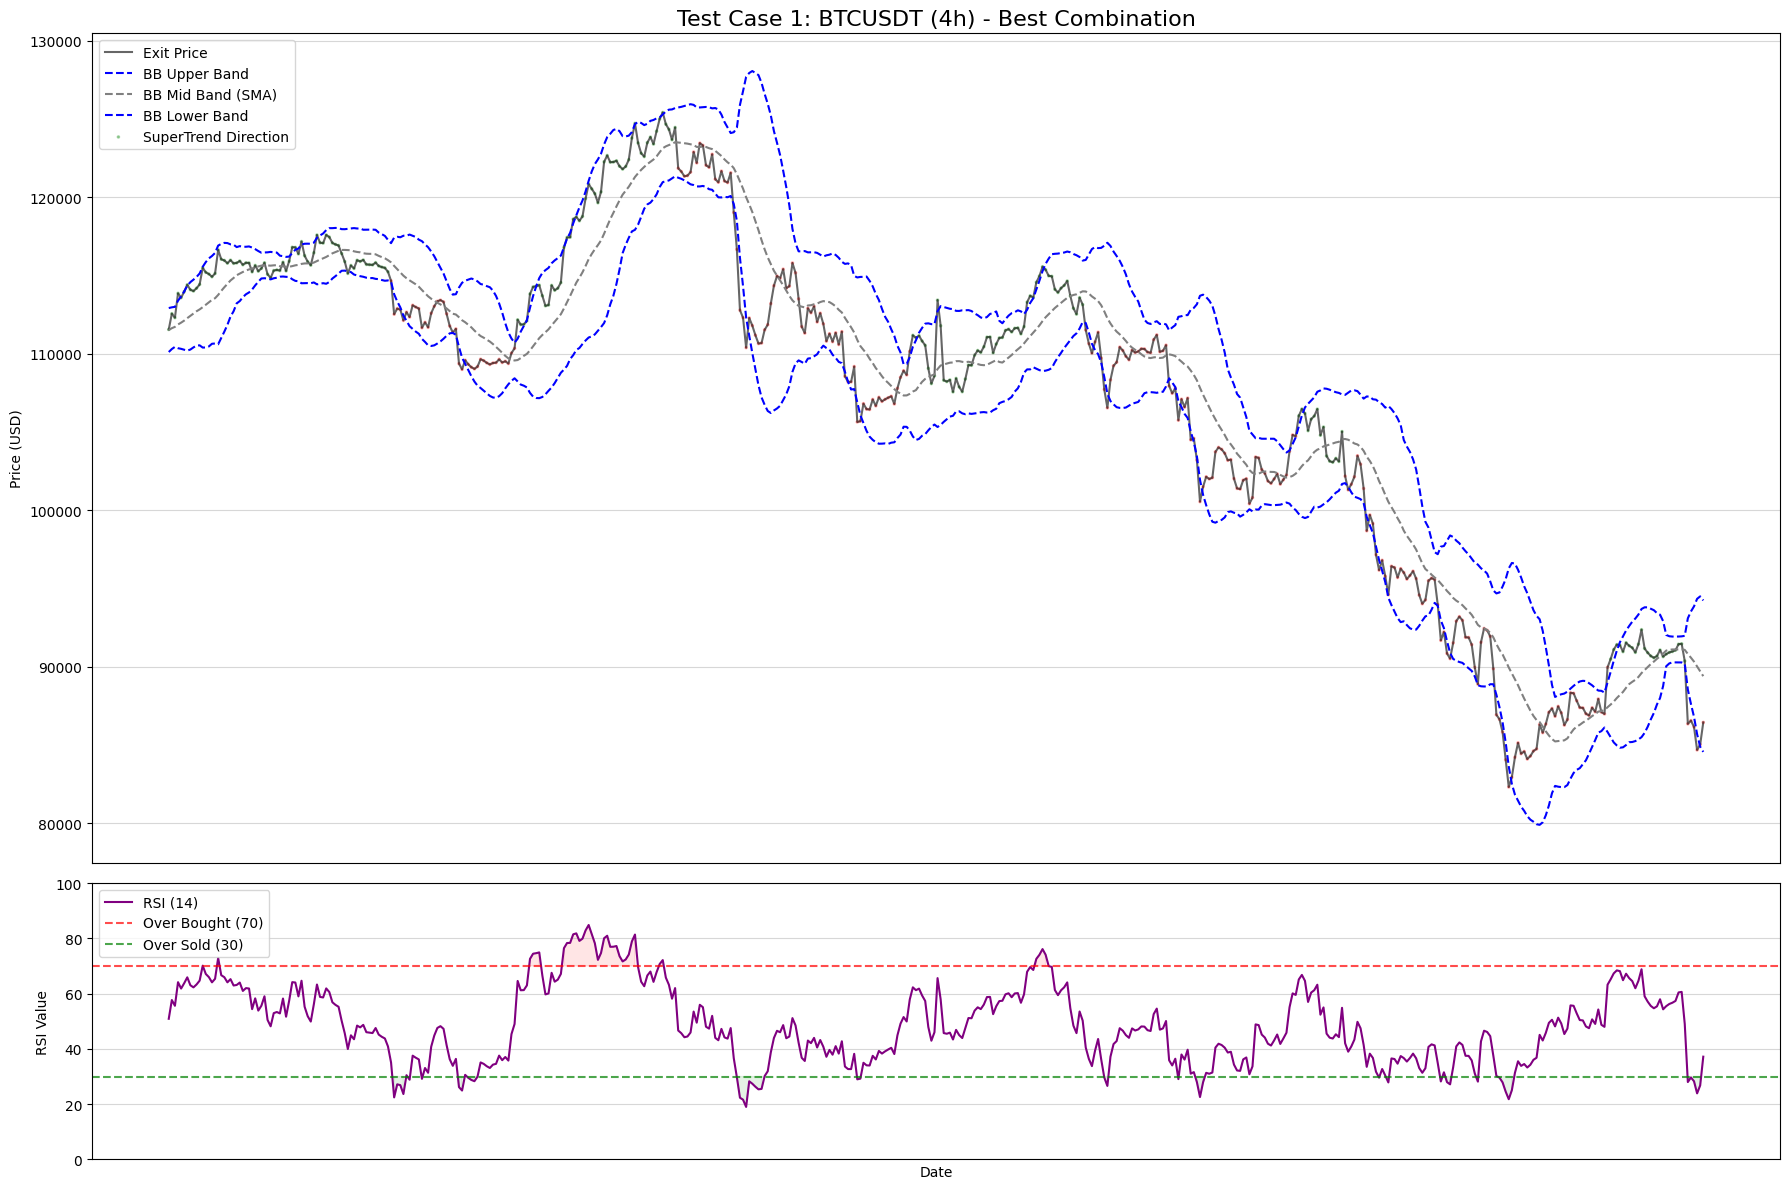

✅ BTCUSDT chart created successfully.

--- Chart data loading: ETHUSDT (4h) ---
✅ Backtest data loaded: 600 rows from 100 days ago UTC
✅ Indicators calculated successfully. 498 rows available.


C:\Users\mst29\AppData\Local\Temp\ipykernel_4844\1811317306.py:35: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  buy_dates_raw = pd.Index(pd.to_datetime(buy_signals['Date']).dt.floor('S'))
C:\Users\mst29\AppData\Local\Temp\ipykernel_4844\1811317306.py:36: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  sell_dates_raw = pd.Index(pd.to_datetime(sell_signals['Date']).dt.floor('S'))


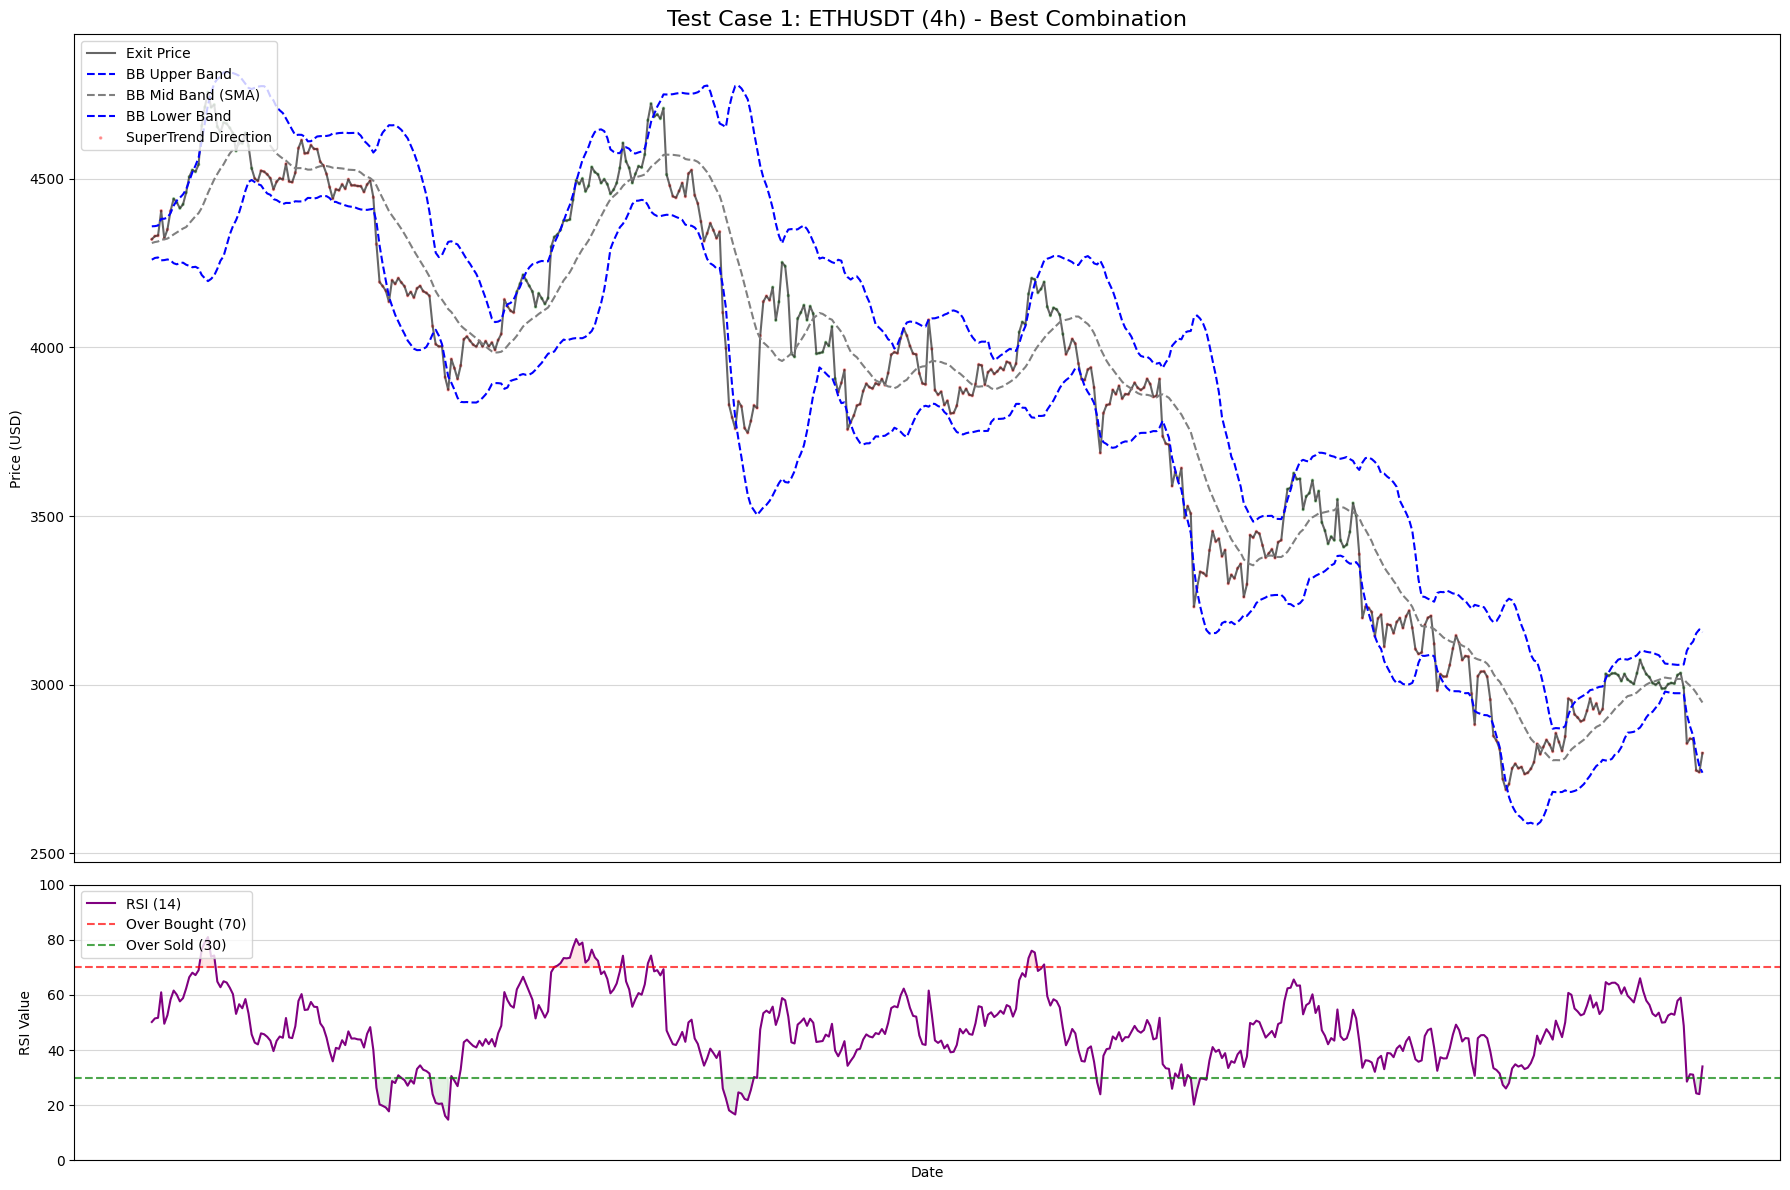

✅ ETHUSDT chart created successfully.


In [7]:
# CHARTS

# Plots price, indicators and buy/sell signals for the specified best combination
def plot_best_strategy(combo, trade_list):
    if combo is None or trade_list.empty:
        print(f"⚠️ {combo['Asset']} no completed transaction details found. Graph cannot be drawn.")
        return

    asset = combo['Asset']
    tf = combo['Timeframe']
    buy_dates, sell_dates = pd.Index([]), pd.Index([])
    buy_prices, sell_prices = pd.Series(), pd.Series()

    print(f"\n--- Chart data loading: {asset} ({tf}) ---")
    try:
        # Load and Process the Best Dataset
        historical_data = data_loader.download_crypto_data_interval_backtest(
            api_key=os.getenv("BINANCE_API_KEY"),
            api_secret=os.getenv("BINANCE_API_SECRET"),
            symbol=asset,
            interval=tf,
            check_date="100 days ago UTC" # A shorter period can be selected for the chart
        )
        df_chart = indicator_calculator.calculate_indicators(historical_data)
        df_chart.index = pd.to_datetime(df_chart.index)

    except Exception as e:
        print(f"❌ ERROR: {asset} An error occurred while loading/calculating data: {e}")
        return
    
    buy_signals = trade_list[trade_list['Action'] == 'BUY']
    sell_signals = trade_list[trade_list['Action'] == 'SELL'] 
    
    # Convert signal dates to DatetimeIndex
    buy_dates_raw = pd.Index(pd.to_datetime(buy_signals['Date']).dt.floor('S'))
    sell_dates_raw = pd.Index(pd.to_datetime(sell_signals['Date']).dt.floor('S'))
    # Select existing dates in df_chart.index:
    valid_buy_dates = buy_dates_raw.intersection(df_chart.index)
    valid_sell_dates = sell_dates_raw.intersection(df_chart.index)
    
    # Finding signal prices on DatetimeIndex
    buy_prices = df_chart.loc[valid_buy_dates, 'Close'].dropna()
    sell_prices = df_chart.loc[valid_sell_dates, 'Close'].dropna()

    # Creating Graphics
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # ----------------- TOP GRAPH (Price, BB, SuperTrend) -----------------
    ax1.plot(df_chart.index, df_chart['Close'], label='Exit Price', color='black', alpha=0.6)

    # Bollinger Bands
    ax1.plot(df_chart.index, df_chart['BB_upper'], label='BB Upper Band', color='blue', linestyle='--')
    ax1.plot(df_chart.index, df_chart['BB_middle'], label='BB Mid Band (SMA)', color='gray', linestyle='--')
    ax1.plot(df_chart.index, df_chart['BB_lower'], label='BB Lower Band', color='blue', linestyle='--')

    # SuperTrend Direction Display
    ax1.scatter(df_chart.index, 
                df_chart['Close'], 
                c=df_chart['ST_DIR'].apply(lambda x: 'green' if x == 1 else 'red'),
                marker='.', s=10, alpha=0.3, label='SuperTrend Direction')

    # Buy/Sell Signals (▲ Buy, × Sell)
    if not buy_prices.empty:
        ax1.scatter(valid_buy_dates, buy_prices, label='Buy (Entry)', marker='^', color='green', s=200, zorder=10)
    if not sell_prices.empty:
        ax1.scatter(valid_sell_dates, sell_prices, label='Sell (Exit)', marker='x', color='red', s=200, linewidths=2, zorder=10)

    ax1.set_title(f'Test Case 1: {asset} ({tf}) - Best Combination', fontsize=16)
    ax1.set_ylabel('Price (USD)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.5)

    # ----------------- BOTTOM GRAPH (RSI) -----------------
    ax2.plot(df_chart.index, df_chart['rsi'], label='RSI (14)', color='purple')

    # RSI Overbought/Oversold Levels
    ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Over Bought (70)')
    ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Over Sold (30)')
    ax2.fill_between(df_chart.index, 70, df_chart['rsi'], where=(df_chart['rsi'] > 70), color='red', alpha=0.1)
    ax2.fill_between(df_chart.index, 30, df_chart['rsi'], where=(df_chart['rsi'] < 30), color='green', alpha=0.1)

    ax2.set_ylabel('RSI Value')
    ax2.set_xlabel('Date')
    ax2.set_ylim(0, 100)
    ax2.grid(True, alpha=0.5)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()
    print(f"✅ {asset} chart created successfully.")

# BTCUSDT Graph
plot_best_strategy(btc_combo, btc_trade_list)

# ETHUSDT Graph
plot_best_strategy(eth_combo, eth_trade_list)

In [8]:
"""
    CASE 2
"""

'\n    CASE 2\n'

In [9]:
# Imports
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from Bot import TradingBot
from Indicator.calculator import IndicatorCalculator
from Data_Initializer.initializer import DataLoader
from Patterns.Strategies.IchimokuCustomStrategy import IchimokuCustomStrategy
from Patterns.Observer import LoggingObserver 

In [10]:
# Rules
ASSETS = ["BTCUSDT", "ETHUSDT"]
TIMEFRAMES = ["1h", "4h", "1d"] 
BACKTEST_START_DATE = "1 Jan, 2022"

# Note: Table to be compared with Case 1 RESULTS_DF
CUSTOM_RESULTS_DF = pd.DataFrame(columns=[
    'Asset', 'Timeframe', 'Entry_Rule', 'Exit_Rule', 
    'Total_PnL_USD', 'Win_Rate', 'Completed_Trades'
])

CASE2_LOG_FILE = "case2_ichimoku_log.txt"

In [11]:
# Ichimoku & Custom Rule loop & PERFORMANCE TABLES

ichimoku_logger = LoggingObserver(log_file=CASE2_LOG_FILE)
data_loader = DataLoader()
indicator_calculator = IndicatorCalculator()

for asset in ASSETS:
    for tf in TIMEFRAMES:
        
        print(f"\n--- 📥 Loading data for: {asset} / {tf} ---")
        
        # Load Data (API)
        try:
            historical_data = data_loader.download_crypto_data_interval_backtest(
                api_key=os.getenv("BINANCE_API_KEY"),
                api_secret=os.getenv("BINANCE_API_SECRET"),
                symbol=asset,
                interval=tf,
                check_date=BACKTEST_START_DATE 
            )
            df_processed = indicator_calculator.calculate_indicators(historical_data)
            if df_processed.empty:
                print(f"⚠️ {asset}/{tf} No valid data found. Skipping.")
                continue
        except Exception as e:
            print(f"❌ERROR: Data extraction/processing error ({asset}/{tf}): {e}. Skipping.")
            continue

        print(f"   Testing: Ichimoku Custom Rule...")
        #Adjust Strategy (One Rule)
        current_strategy = IchimokuCustomStrategy(stop_loss=0.02)
        
        bot = TradingBot(coin_symbol=asset)
        bot.set_strategy(current_strategy)
        bot.register_observer(ichimoku_logger) # register the logger
        
        # Run Backtest
        final_balance = bot.backtest_trading(
            initial_balance=10000,
            stop_loss=0.02,
            df_with_indicators=df_processed,
            position_size_pct=1.0
        )

        # Save Results
        pnl = final_balance - 10000
        stats = bot.get_trade_statistics()

        new_row = {
            'Asset': asset,
            'Timeframe': tf,
            # Return values of IchimokuCustomStrategy
            'Entry_Rule': 'IchimokuEntry', 
            'Exit_Rule': 'CustomExit/SL',
            'Total_PnL_USD': round(pnl, 2),
            'Final_Balance': round(final_balance, 5),
            'Win_Rate': round(stats['win_rate'], 4),
            'Completed_Trades': stats['completed_trades']
        }

        CUSTOM_RESULTS_DF.loc[len(CUSTOM_RESULTS_DF)] = new_row

CUSTOM_RESULTS_FILE = "case2_ichimoku_results.csv"
CUSTOM_RESULTS_DF.to_csv(CUSTOM_RESULTS_FILE, index=False)
print("\n" + "="*70)
print("✅ TEST CASE 2: ICHIMOKU CUSTOM RULE RESULT SUMMARY")
print(CUSTOM_RESULTS_DF.to_markdown(index=False))
print("="*70)
print(f"📊 All Grid Results Saved: {CUSTOM_RESULTS_FILE}")
print(f"📝 Detailed Logs Recorded: {CASE2_LOG_FILE}")

[LOG] LoggingObserver initialized - Log target: case2_ichimoku_log.txt

--- 📥 Loading data for: BTCUSDT / 1h ---
✅ Backtest data loaded: 34342 rows from 1 Jan, 2022
✅ Indicators calculated successfully. 34240 rows available.
   Testing: Ichimoku Custom Rule...
🤖 TradingBot initialized for BTCUSDT
✅ Observer registered: LoggingObserver

🔙 Starting BACKTEST for BTCUSDT
   Initial Balance: $10000.00
   Position Size: 100.0%
📊 Processing 34240 candles...

📊 Backtest Complete!
   Final Balance: $10000.00
   Profit/Loss: $0.00 (0.00%)



--- 📥 Loading data for: BTCUSDT / 4h ---
✅ Backtest data loaded: 8586 rows from 1 Jan, 2022
✅ Indicators calculated successfully. 8484 rows available.
   Testing: Ichimoku Custom Rule...
🤖 TradingBot initialized for BTCUSDT
✅ Observer registered: LoggingObserver

🔙 Starting BACKTEST for BTCUSDT
   Initial Balance: $10000.00
   Position Size: 100.0%
📊 Processing 8484 candles...

📊 Backtest Complete!
   Final Balance: $10000.00
   Profit/Loss: $0.00 (0.00%)




In [12]:
# BEST TF OF ICHIMOKU
TARGET_RESULTS_BTC = CUSTOM_RESULTS_DF[CUSTOM_RESULTS_DF['Asset'] == "BTCUSDT"]
TARGET_RESULTS_ETH = CUSTOM_RESULTS_DF[CUSTOM_RESULTS_DF['Asset'] == "ETHUSDT"]

best_combo_btc = TARGET_RESULTS_BTC.sort_values(by='Total_PnL_USD', ascending=False).iloc[0]
best_combo_eth = TARGET_RESULTS_ETH.sort_values(by='Total_PnL_USD', ascending=False).iloc[0]

print("\n" + "="*80)
print("🏆 BTCUSDT BEST TF CHOSEN:")
print(f"   Time Frame: {best_combo_btc['Timeframe']}, Entry Rule: {best_combo_btc['Entry_Rule']}, Exit Rule: {best_combo_btc['Exit_Rule']}")
print(f"   Total Profit/Loss: ${best_combo_btc['Total_PnL_USD']:.2f}")

print("\n" + "="*80)
print("🏆 ETHUSDT BEST TF CHOSEN:")
print(f"   Time Frame: {best_combo_eth['Timeframe']}, Entry Rule: {best_combo_eth['Entry_Rule']}, Exit Rule: {best_combo_eth['Exit_Rule']}")
print(f"   Total Profit/Loss: ${best_combo_eth['Total_PnL_USD']:.2f}")


🏆 BTCUSDT BEST TF CHOSEN:
   Time Frame: 1h, Entry Rule: IchimokuEntry, Exit Rule: CustomExit/SL
   Total Profit/Loss: $0.00

🏆 ETHUSDT BEST TF CHOSEN:
   Time Frame: 1h, Entry Rule: IchimokuEntry, Exit Rule: CustomExit/SL
   Total Profit/Loss: $0.00


✅ Backtest data loaded: 2400 rows from 100 days ago UTC
✅ Indicators calculated successfully. 2298 rows available.


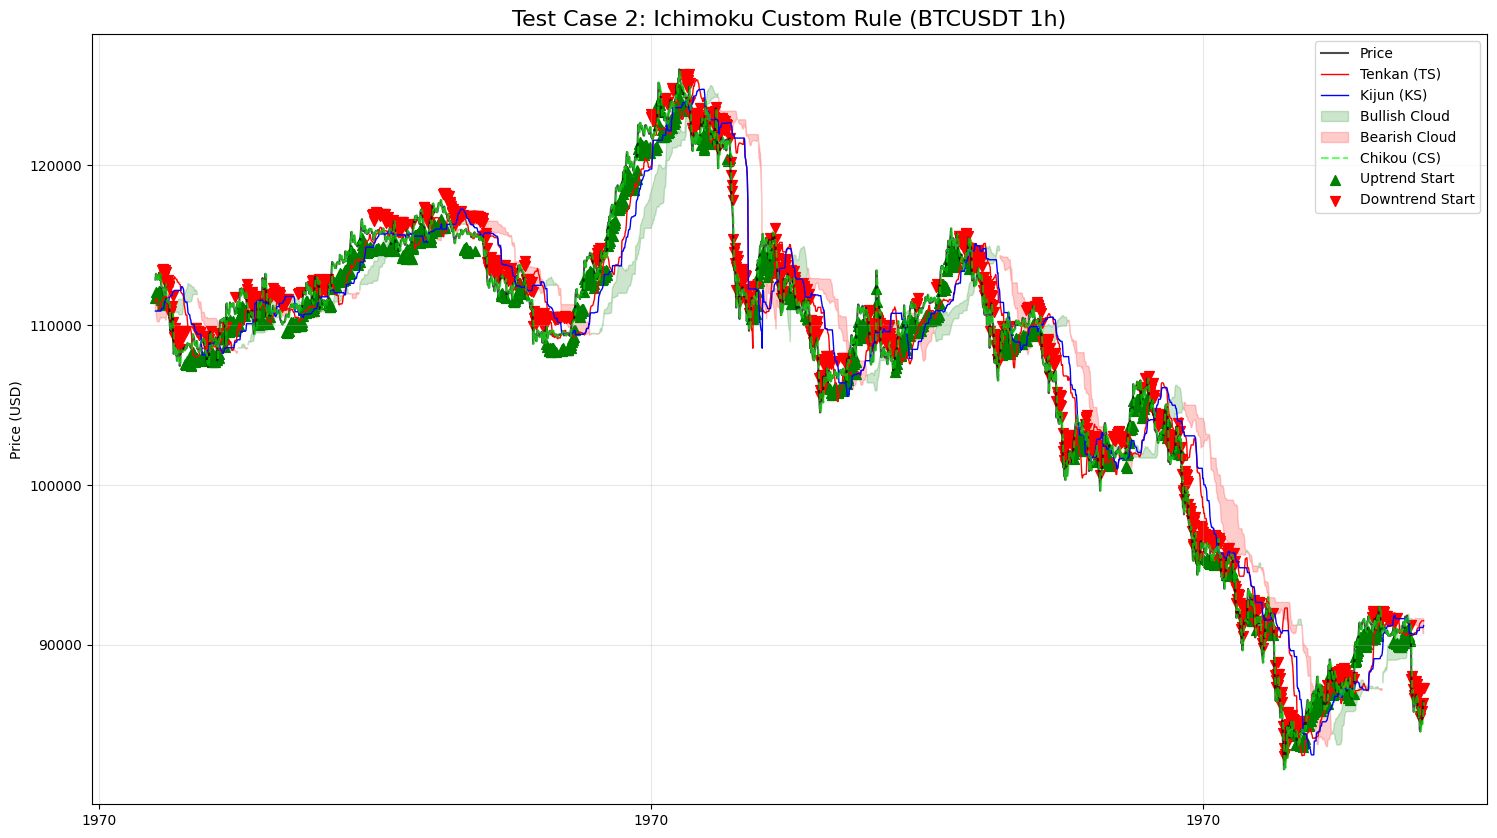

✅ BTCUSDT chart created successfully.

✅ Backtest data loaded: 2400 rows from 100 days ago UTC
✅ Indicators calculated successfully. 2298 rows available.


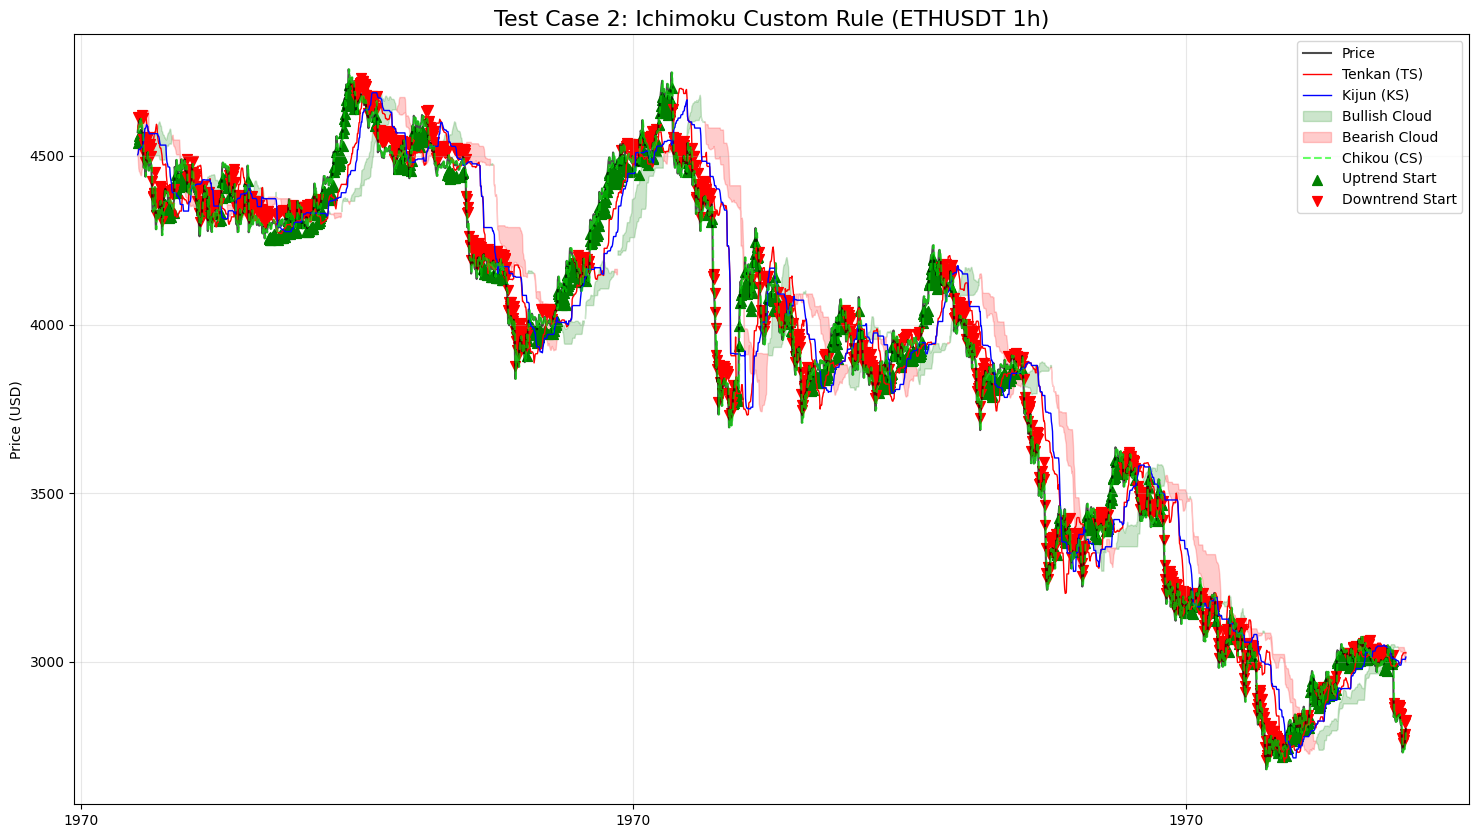

✅ ETHUSDT chart created successfully.



In [13]:
#CHARTS

def plot_ichimoku_with_signal(ASSET_TO_PLOT: str, tf: str):
    try:
        historical_data = data_loader.download_crypto_data_interval_backtest(
            api_key=os.getenv("BINANCE_API_KEY"),
            api_secret=os.getenv("BINANCE_API_SECRET"),
            symbol=ASSET_TO_PLOT,
            interval=tf,
            check_date="100 days ago UTC" # A shorter period can be selected for the chart
        )
        df_chart = indicator_calculator.calculate_indicators(historical_data)
        df_chart.index = pd.to_datetime(df_chart.index)
    
    except Exception as e:
        print(f"❌ ERROR: Failed to load chart data: {e}")
        sys.exit()
    
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 10))
    
    # Price and Ichimoku Lines
    ax1.plot(df_chart.index, df_chart['Close'], label='Price', color='black', alpha=0.7)
    ax1.plot(df_chart.index, df_chart['Tenkan-sen'], label='Tenkan (TS)', color='red', linewidth=1)
    ax1.plot(df_chart.index, df_chart['Kijun-sen'], label='Kijun (KS)', color='blue', linewidth=1)
    
    # Cloud (Kumo) Drawing (fill_between)
    ax1.fill_between(df_chart.index, 
                     df_chart['Senkou Span A'], 
                     df_chart['Senkou Span B'], 
                     where=df_chart['Senkou Span A'] >= df_chart['Senkou Span B'],
                     color='green', alpha=0.2, label='Bullish Cloud')
    
    ax1.fill_between(df_chart.index, 
                     df_chart['Senkou Span A'], 
                     df_chart['Senkou Span B'], 
                     where=df_chart['Senkou Span A'] < df_chart['Senkou Span B'],
                     color='red', alpha=0.2, label='Bearish Cloud')
    
    # Chikou Span
    ax1.plot(df_chart.index, df_chart['Chikou Span'], label='Chikou (CS)', color='lime', alpha=0.6, linestyle='--')
    
    # Market Structure Signals (Trend Filter instead of HH/HL/LH/LL)
    # Mark market structure change/trend just above or below price
    uptrend_start = df_chart[df_chart['MARKET_STRUCTURE_TREND'] == 'UPTREND'].index
    downtrend_start = df_chart[df_chart['MARKET_STRUCTURE_TREND'] == 'DOWNTREND'].index
    
    ax1.scatter(uptrend_start, df_chart.loc[uptrend_start, 'Close'] * 0.99, marker='$\u25B2$', # Üçgen
                color='green', s=50, label='Uptrend Start')
    ax1.scatter(downtrend_start, df_chart.loc[downtrend_start, 'Close'] * 1.01, marker='$\u25BC$', # Ters Üçgen
                color='red', s=50, label='Downtrend Start')
        
    ax1.set_title(f'Test Case 2: Ichimoku Custom Rule ({ASSET_TO_PLOT} {tf})', fontsize=16)
    ax1.set_ylabel('Price (USD)')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    plt.show()
    print(f"✅ {ASSET_TO_PLOT} chart created successfully.\n")

plot_ichimoku_with_signal('BTCUSDT', best_combo_btc['Timeframe'])
plot_ichimoku_with_signal('ETHUSDT', best_combo_eth['Timeframe'])

In [14]:
# COMPARISON OF CASE 1 AND 2

# Case 1 Loading Grid Results
try:
    GRID_RESULTS_DF = pd.read_csv("case1_grid_search_results.csv")
    GRID_RESULTS_DF['Strategy_Type'] = 'Grid (C1)'
except FileNotFoundError:
    print("❌ ERROR: Grid Search results ('case1_grid_search_results.csv') not found.")
    sys.exit()

# Loading Case 2 Custom Results
try:
    CUSTOM_RESULTS_DF = pd.read_csv("case2_ichimoku_results.csv")
    CUSTOM_RESULTS_DF['Strategy_Type'] = 'Ichimoku (C2)'
except FileNotFoundError:
    print("❌ ERROR: Ichimoku Custom Rule results ('case2_ichimoku_results.csv') not found.")
    sys.exit()

# Find the best PnL for each asset/TF in the Grid
best_grid = GRID_RESULTS_DF.loc[GRID_RESULTS_DF.groupby(['Asset', 'Timeframe'])['Total_PnL_USD'].idxmax()]

# Combine with Custom Rule (Custom is already just 1 rule)
comparison_df = pd.concat([best_grid, CUSTOM_RESULTS_DF])


print("="*80)
print("COMPARISON: BEST GRID (C1) vs ICHIMOKU (C2)")
print("="*80)

for asset in ["BTCUSDT", "ETHUSDT"]:
    print(f"\n--- 📈 {asset} COMPARISON RESULTS ---")
    
    asset_comparison = comparison_df[comparison_df['Asset'] == asset].sort_values(
        by=['Timeframe', 'Total_PnL_USD'], ascending=[True, False]
    )
    
    # Overall ranking by PnL
    final_view = asset_comparison.sort_values(by='Total_PnL_USD', ascending=False)
    print(final_view.to_markdown(index=False))

COMPARISON: BEST GRID (C1) vs ICHIMOKU (C2)

--- 📈 BTCUSDT COMPARISON RESULTS ---
| Asset   | Timeframe   | Entry_Rule    | Exit_Rule     |   Total_PnL_USD |   Win_Rate |   Completed_Trades | Strategy_Type   |
|:--------|:------------|:--------------|:--------------|----------------:|-----------:|-------------------:|:----------------|
| BTCUSDT | 4h          | RSI_25        | ST_BUY        |         16671.8 |        100 |                 22 | Grid (C1)       |
| BTCUSDT | 1h          | RSI_40        | ST_BUY        |         12424   |        100 |                 92 | Grid (C1)       |
| BTCUSDT | 1d          | RSI_40        | ST_BUY        |         10810.6 |        100 |                 15 | Grid (C1)       |
| BTCUSDT | 1d          | IchimokuEntry | CustomExit/SL |             0   |          0 |                  0 | Ichimoku (C2)   |
| BTCUSDT | 1h          | IchimokuEntry | CustomExit/SL |             0   |          0 |                  0 | Ichimoku (C2)   |
| BTCUSDT | 4h        

In [15]:
"""
    CASE 3
"""

'\n    CASE 3\n'

In [16]:
#APPLYYING THE BEST ENTRY & EXIT COMBO FROM CASE 1 & 2 TO OCT-NOV 2025

from typing import List, Dict, Any
FORWARD_TEST_STRATEGIES: List[Dict[str, Any]] = []

for asset in ["BTCUSDT", "ETHUSDT"]:
    # Compare all results (Best of Grid + Custom Rule) by asset
    best_overall_combo = comparison_df[comparison_df['Asset'] == asset].sort_values(
        by='Total_PnL_USD', ascending=False
    ).iloc[0]
    
    FORWARD_TEST_STRATEGIES.append({
        'Asset': best_overall_combo['Asset'],
        'TF': best_overall_combo['Timeframe'],
        'Type': best_overall_combo['Strategy_Type'],
        'Entry': best_overall_combo['Entry_Rule'],
        'Exit': best_overall_combo['Exit_Rule']
    })

print("✅ Strategies for Forward Testing Have Been Determined.")
print("--------------------------------------------------")
for s in FORWARD_TEST_STRATEGIES:
    print(f"[{s['Asset']}] Best Strategy: {s['Type']} ({s['TF']}) (Entry: {s['Entry']}) (Exit: {s['Exit']})")
print("--------------------------------------------------")


# STRUCTURE
load_dotenv()
data_loader = DataLoader()
indicator_calculator = IndicatorCalculator()

FORWARD_TEST_START_DATE = "1 Oct, 2025" 
CASE3_LOG_FILE = "case3_forward_test_log.txt"
forward_logger = LoggingObserver(log_file=CASE3_LOG_FILE)

FORWARD_RESULTS_DF = pd.DataFrame(columns=[
    'Asset', 'Timeframe', 'Entry_Rule', 'Exit_Rule', 'Strategy_Type',
    'Total_PnL_USD', 'Win_Rate', 'Completed_Trades'
])


# FORWARD TEST CYCLE
for strategy_info in FORWARD_TEST_STRATEGIES:
    asset = strategy_info['Asset']
    tf = strategy_info['TF']
    strat_type = strategy_info['Type']
    entry_id = strategy_info['Entry']
    exit_id = strategy_info['Exit']
    
    print(f"\n--- 📥 {strat_type} Verisi Çekiliyor: {asset} / {tf} ---")
    
    # Fetch Data and Calculate Indicators
    try:
        historical_data = data_loader.download_crypto_data_interval_backtest(
            api_key=os.getenv("BINANCE_API_KEY"),
            api_secret=os.getenv("BINANCE_API_SECRET"),
            symbol=asset,
            interval=tf,
            check_date=FORWARD_TEST_START_DATE 
        )
        df_processed = indicator_calculator.calculate_indicators(historical_data)
        
        if df_processed.empty:
            print(f"⚠️ {asset}/{tf} no Valid data. Skipping.")
            continue
            
    except Exception as e:
        print(f"❌ERROR: Data extraction/processing error: {e}. Skipping.")
        continue


    print(f"   Testing: {strat_type}...")
    
    # Prepare strategy (Grid or Ichimoku)
    if 'Grid' in strat_type:
        current_strategy = GridSearchStrategy(entry_id, exit_id, stop_loss=0.02)
    else: # Ichimoku
        current_strategy = IchimokuCustomStrategy(stop_loss=0.02)

    # Prepare and Run the Bot
    bot = TradingBot(coin_symbol=asset)
    bot.set_strategy(current_strategy)
    bot.register_observer(forward_logger) 

    final_balance = bot.backtest_trading(
        initial_balance=10000,
        stop_loss=0.02,
        df_with_indicators=df_processed,
        position_size_pct=1.0
    )

    pnl = final_balance - 10000
    stats = bot.get_trade_statistics()

    new_row = {
        'Asset': asset,
        'Timeframe': tf,
        'Entry_Rule': entry_id, 
        'Exit_Rule': exit_id,
        'Strategy_Type': strat_type,
        'Total_PnL_USD': round(pnl, 2),
        'Win_Rate': round(stats['win_rate'], 4),
        'Completed_Trades': stats['completed_trades']
    }

    FORWARD_RESULTS_DF.loc[len(FORWARD_RESULTS_DF)] = new_row


FORWARD_RESULTS_FILE = "case3_forward_test_results.csv"
FORWARD_RESULTS_DF.to_csv(FORWARD_RESULTS_FILE, index=False)

print("✅ TEST CASE 3: FORWARD TEST SUMMARY")
print(FORWARD_RESULTS_DF.to_markdown(index=False))
print("="*70)
print(f"💾 Results Saved: {FORWARD_RESULTS_FILE}")

✅ Strategies for Forward Testing Have Been Determined.
--------------------------------------------------
[BTCUSDT] Best Strategy: Grid (C1) (4h) (Entry: RSI_25) (Exit: ST_BUY)
[ETHUSDT] Best Strategy: Grid (C1) (4h) (Entry: RSI_25) (Exit: BB_B_0.40)
--------------------------------------------------
[LOG] LoggingObserver initialized - Log target: case3_forward_test_log.txt

--- 📥 Grid (C1) Verisi Çekiliyor: BTCUSDT / 4h ---
✅ Backtest data loaded: 372 rows from 1 Oct, 2025
✅ Indicators calculated successfully. 270 rows available.
   Testing: Grid (C1)...
🤖 TradingBot initialized for BTCUSDT
✅ Observer registered: LoggingObserver

🔙 Starting BACKTEST for BTCUSDT
   Initial Balance: $10000.00
   Position Size: 100.0%
📊 Processing 270 candles...
ℹ️ Backtest sonu: Kalan pozisyon 0.13407183641244824 adet BTCUSDT $86472.53 fiyattan satıldı.

📊 Backtest Complete!
   Final Balance: $11593.53
   Profit/Loss: $1593.53 (15.94%)



--- 📥 Grid (C1) Verisi Çekiliyor: ETHUSDT / 4h ---
✅ Backtest dat